In [3]:
# ============================================
# SCRIPT 1: SETUP — Initializes all sentiment analyzers
# Run this FIRST. It creates the `analyzer` object used by Script 3.
# ============================================
import os
import time
import pandas as pd
import numpy as np
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
import torch

# ============================================
# MODEL INITIALIZATION
# ============================================

class SentimentAnalyzer:
    def __init__(self, your_model_repo="Kaizen696/my_lead_model"):
        print("🔧 Initializing sentiment analyzers...")

        # --- 1. TextBlob (Local / Rule-based) ---
        print("✓ TextBlob ready")

        # --- 2. VADER (Local / Rule-based) ---
        self.vader = SentimentIntensityAnalyzer()
        print("✓ VADER ready")

        # --- 3. DistilBERT SST-2 (Local / Baseline) ---
        print("⏳ Loading DistilBERT (SST-2 baseline)...")
        self.distilbert = pipeline(
            "sentiment-analysis",
            model="distilbert-base-uncased-finetuned-sst-2-english",
            device=-1
        )
        print("✓ DistilBERT ready")

        # --- 4. Twitter-RoBERTa (Local / Slang) ---
        print("⏳ Loading Twitter-RoBERTa...")
        self.twitter_roberta = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-roberta-base-sentiment-latest",
            device=-1
        )
        print("✓ Twitter-RoBERTa ready")

        # --- 5. Your Fine-Tuned Model (v2 — domain adapted) ---
        print(f"⏳ Loading your model ({your_model_repo})...")
        self.your_model = pipeline(
            "text-classification",
            model=your_model_repo,
            device=-1
        )
        print("✓ Your model ready")

        print("\n🎉 All models initialized!\n")

    # ============================================
    # ANALYZER METHODS
    # ============================================

    def textblob_analyze(self, text):
        polarity = TextBlob(text).sentiment.polarity
        if polarity > 0.1:
            return "POSITIVE", polarity
        elif polarity < -0.1:
            return "NEGATIVE", polarity
        else:
            return "NEUTRAL", polarity

    def vader_analyze(self, text):
        scores = self.vader.polarity_scores(text)
        compound = scores['compound']
        if compound >= 0.05:
            return "POSITIVE", compound
        elif compound <= -0.05:
            return "NEGATIVE", compound
        else:
            return "NEUTRAL", compound

    def distilbert_analyze(self, text):
        result = self.distilbert(text[:512])[0]
        label = result['label']
        score = result['score'] if label == 'POSITIVE' else -result['score']
        return label, score

    def twitter_roberta_analyze(self, text):
        result = self.twitter_roberta(text[:512])[0]
        label_map = {'positive': 'POSITIVE', 'negative': 'NEGATIVE', 'neutral': 'NEUTRAL'}
        label = label_map.get(result['label'].lower(), result['label'].upper())
        score = result['score'] if 'positive' in result['label'].lower() else -result['score']
        return label, score

    def your_model_analyze(self, text):
        result = self.your_model(text[:512])[0]
        # IMPORTANT: verify these against your model's actual config.json id2label
        # before trusting benchmark results — don't assume this mapping is correct.
        raw_label = result['label'].upper()
        label_map = {
            'LABEL_0': 'NEGATIVE', 'NEGATIVE': 'NEGATIVE',
            'LABEL_1': 'NEUTRAL', 'NEUTRAL': 'NEUTRAL',
            'LABEL_2': 'POSITIVE', 'POSITIVE': 'POSITIVE'
        }
        label = label_map.get(raw_label, raw_label)
        score = result['score'] if label == 'POSITIVE' else (-result['score'] if label == 'NEGATIVE' else 0.0)
        return label, score

    def analyze_all(self, text):
        results = {}
        results['TextBlob'] = self.textblob_analyze(text)
        results['VADER'] = self.vader_analyze(text)
        results['DistilBERT (SST-2 baseline)'] = self.distilbert_analyze(text)
        results['Twitter-RoBERTa'] = self.twitter_roberta_analyze(text)
        results['Your Model (v2)'] = self.your_model_analyze(text)
        return results

    def compare_on_dataset(self, texts, true_labels=None):
        """Run all models on a list of texts, return a DataFrame for comparison."""
        rows = []
        for i, text in enumerate(texts):
            results = self.analyze_all(text)
            row = {"text": text}
            for model_name, (label, score) in results.items():
                row[f"{model_name}_label"] = label
                row[f"{model_name}_score"] = round(score, 4)
            if true_labels is not None:
                row["true_label"] = true_labels[i]
            rows.append(row)
        return pd.DataFrame(rows)

# ============================================
# MAIN EXECUTION (quick smoke test)
# ============================================
if __name__ == "__main__":
    analyzer = SentimentAnalyzer()

    print("="*50)
    print("✅ SETUP COMPLETE!")
    print("="*50)

    test_cases = [
        "Not interested at all. They are happy with their current vendor.",
        "Really impressed, asked for the contract right after the call.",
        "Still weighing a few options, nothing decided yet.",
        "Budget is approved, excited to move forward.",
        "Too expensive, they went with a competitor."
    ]

    print("\n🚀 Comparing models on test cases:\n")
    df = analyzer.compare_on_dataset(test_cases)
    pd.set_option('display.max_colwidth', 40)
    print(df.to_string(index=False))

    df.to_csv("model_comparison.csv", index=False)
    print("\n💾 Saved comparison to model_comparison.csv")

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cpu for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0822 00:05:57.336000 38160 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


🔧 Initializing sentiment analyzers...
✓ TextBlob ready
✓ VADER ready
⏳ Loading DistilBERT (SST-2 baseline)...


Device set to use cpu


✓ DistilBERT ready
⏳ Loading Twitter-RoBERTa...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


✓ Twitter-RoBERTa ready
⏳ Loading your model (Kaizen696/my_lead_model)...


Device set to use cpu


✓ Your model ready

🎉 All models initialized!

✅ SETUP COMPLETE!

🚀 Comparing models on test cases:

                                                            text TextBlob_label  TextBlob_score VADER_label  VADER_score DistilBERT (SST-2 baseline)_label  DistilBERT (SST-2 baseline)_score Twitter-RoBERTa_label  Twitter-RoBERTa_score Your Model (v2)_label  Your Model (v2)_score
Not interested at all. They are happy with their current vendor.       POSITIVE          0.2250    POSITIVE       0.3489                          POSITIVE                             0.9995              NEGATIVE                -0.5832              POSITIVE                 0.8365
  Really impressed, asked for the contract right after the call.       POSITIVE          0.6429    POSITIVE       0.5256                          POSITIVE                             0.9994              POSITIVE                 0.9757              POSITIVE                 0.9635
              Still weighing a few options, nothing decided

In [4]:
# ============================================
# SCRIPT 2: DATASET — Loads real benchmark data from Hugging Face
# Run this SECOND (after Script 1). It creates `df_test` used by Script 3.
# Source: https://huggingface.co/datasets/Financial-Sentiment-Analysis/datasets
# ============================================
import pandas as pd
from datasets import load_dataset

# Label mapping confirmed from the source dataset's card:
# 0 = NEUTRAL, 1 = POSITIVE, 2 = NEGATIVE
LABEL_MAP = {0: "NEUTRAL", 1: "POSITIVE", 2: "NEGATIVE"}

SAMPLES_PER_CLASS = 100  # 100/class = 300 total rows. Adjust as needed.
RANDOM_SEED = 42

print("📥 Loading Financial-Sentiment-Analysis/datasets (test split)...")
hf_dataset = load_dataset("Financial-Sentiment-Analysis/datasets", split="test")

df_full = hf_dataset.to_pandas()
df_full["true_label"] = df_full["sentiment"].map(LABEL_MAP)
df_full = df_full.rename(columns={"tweet": "text"})[["text", "true_label"]]

df_full = df_full.dropna(subset=["text", "true_label"])
df_full = df_full[df_full["text"].str.strip() != ""]
df_full = df_full.drop_duplicates(subset=["text"])

df_test = (
    df_full.groupby("true_label", group_keys=False)
    .apply(lambda g: g.sample(n=min(SAMPLES_PER_CLASS, len(g)), random_state=RANDOM_SEED))
    .sample(frac=1, random_state=RANDOM_SEED)  # shuffle final order
    .reset_index(drop=True)
)

print(f"📊 Test dataset: {len(df_test)} samples (stratified from HF test split)")
print(f"   - POSITIVE: {(df_test['true_label']=='POSITIVE').sum()}")
print(f"   - NEGATIVE: {(df_test['true_label']=='NEGATIVE').sum()}")
print(f"   - NEUTRAL: {(df_test['true_label']=='NEUTRAL').sum()}")

if __name__ == "__main__":
    df_test.to_csv("benchmark_dataset.csv", index=False)
    print("\n💾 Saved to benchmark_dataset.csv")

📥 Loading Financial-Sentiment-Analysis/datasets (test split)...
📊 Test dataset: 300 samples (stratified from HF test split)
   - POSITIVE: 100
   - NEGATIVE: 100
   - NEUTRAL: 100

💾 Saved to benchmark_dataset.csv


C:\Users\yashs\AppData\Local\Temp\ipykernel_38160\2393435983.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(SAMPLES_PER_CLASS, len(g)), random_state=RANDOM_SEED))



🔄 Running comparison on 300 texts...

[1/300] user: AAP Not loving that close.  ong weekly 450 c...
  TextBlob                      : NEGATIVE (-0.300)
  VADER                         : NEGATIVE (-0.165)
  DistilBERT (SST-2 baseline)   : NEGATIVE (-0.999)
  Twitter-RoBERTa               : NEGATIVE (-0.848)
  Your Model (v2)               : NEGATIVE (-0.480)

[2/300] $COMDX: Natural gas inventory showed a draw of 115...
  TextBlob                      : NEUTRAL  (+0.050)
  VADER                         : POSITIVE (+0.361)
  DistilBERT (SST-2 baseline)   : NEGATIVE (-0.993)
  Twitter-RoBERTa               : NEUTRAL  (-0.903)
  Your Model (v2)               : NEGATIVE (-0.461)

[3/300] Tory manifesto leaves door open to no-deal Brexit ...
  TextBlob                      : NEUTRAL  (+0.000)
  VADER                         : NEUTRAL  (+0.000)
  DistilBERT (SST-2 baseline)   : NEGATIVE (-0.999)
  Twitter-RoBERTa               : NEUTRAL  (-0.512)
  Your Model (v2)               : NEGATIVE (-

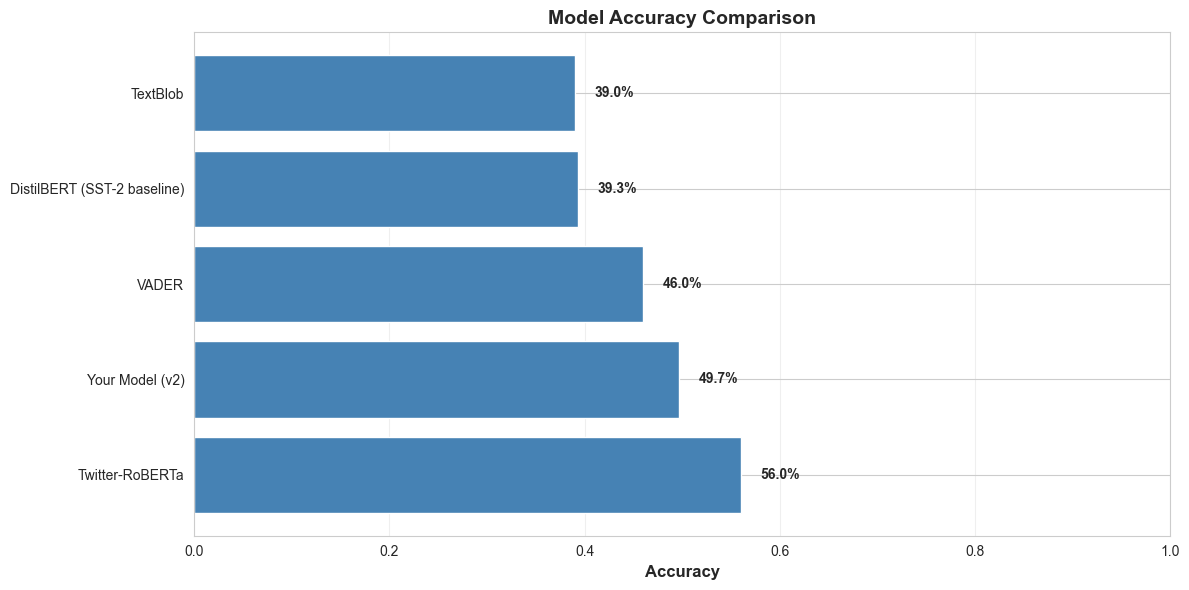

💾 Saved: sentiment_confusion_matrices.png


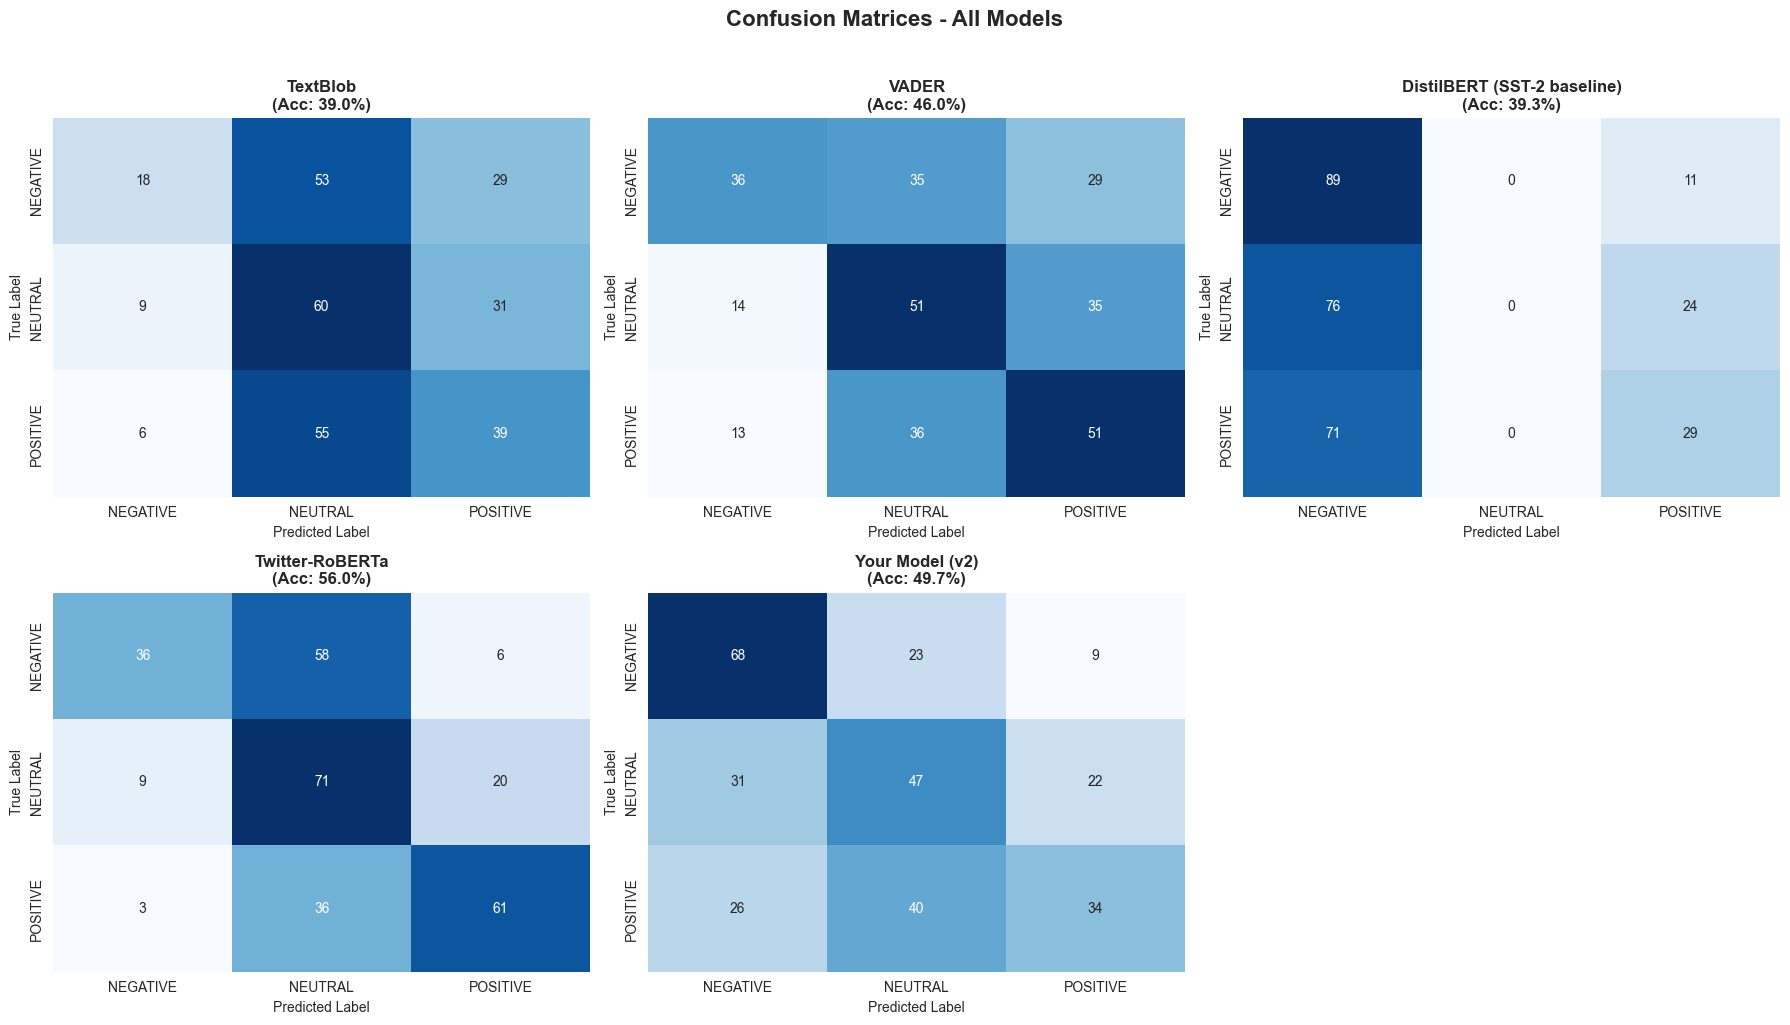

💾 Saved: sentiment_score_distribution.html


💾 Saved: sentiment_model_agreement.png


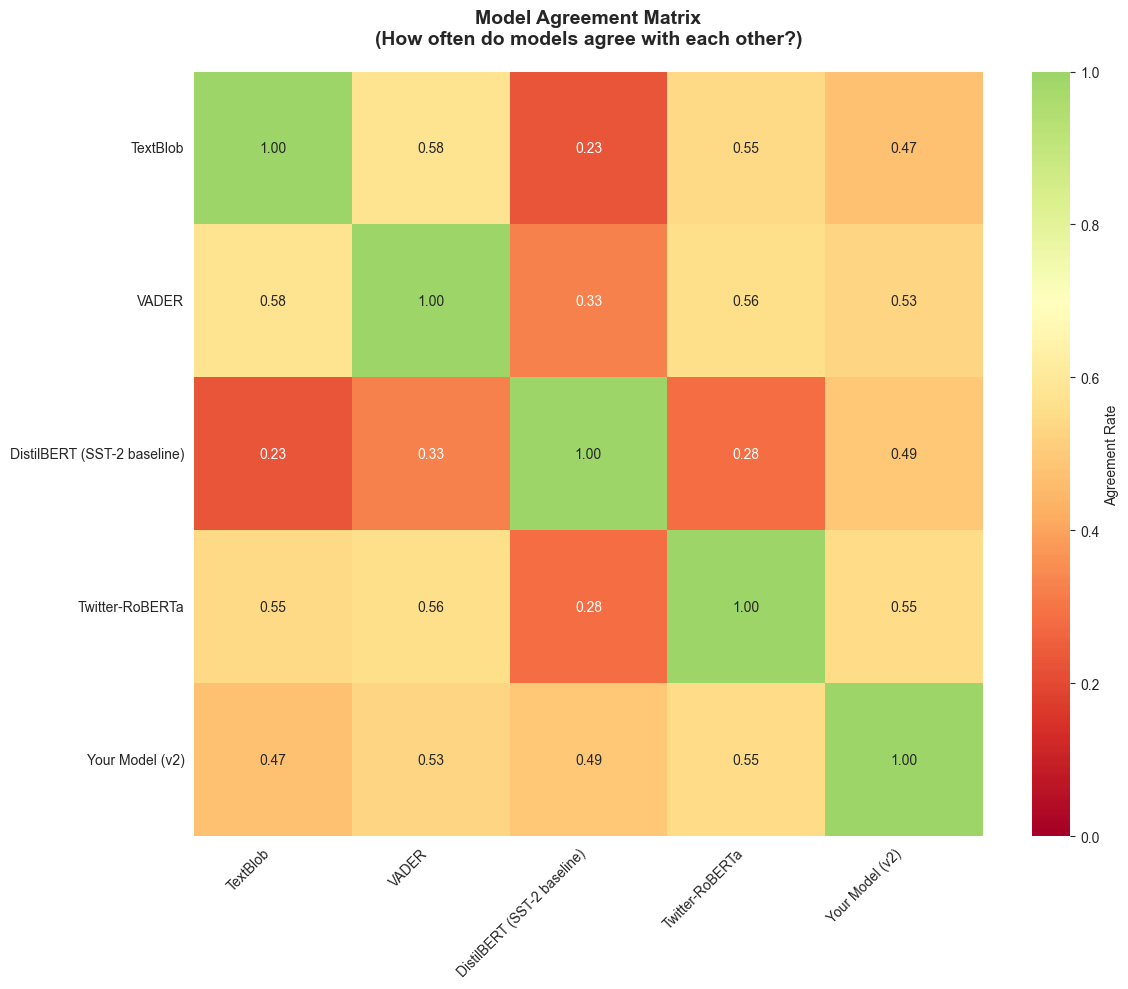

💾 Saved: sentiment_performance_by_type.html



✅ ALL VISUALIZATIONS COMPLETE!

Files saved:
  📊 sentiment_accuracy_comparison.png
  📊 sentiment_confusion_matrices.png
  📊 sentiment_score_distribution.html (interactive)
  📊 sentiment_model_agreement.png
  📊 sentiment_performance_by_type.html (interactive)
  📄 sentiment_comparison_results.csv
  📄 sentiment_metrics_summary.csv


In [5]:
# ============================================
# SCRIPT 3: COMPARISON + VISUALIZATIONS
# Run this THIRD, after Script 1 (creates `analyzer`) and Script 2 (creates `df_test`).
#
# If running as three separate files in the same session (e.g. Jupyter/Colab),
# just run 1_setup_models.py and 2_load_dataset.py first — `analyzer` and
# `df_test` will already be in memory. Otherwise, uncomment the two lines below.
# ============================================
# from importlib import import_module
# analyzer = import_module("1_setup_models").SentimentAnalyzer()
# df_test = import_module("2_load_dataset").df_test

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix, accuracy_score

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================
# RUN COMPARISON
# ============================================

model_names = ['TextBlob', 'VADER', 'DistilBERT (SST-2 baseline)', 'Twitter-RoBERTa', 'Your Model (v2)']

def run_comparison(analyzer, df):
    """Run all models on test data and collect results."""
    results = []

    print(f"\n🔄 Running comparison on {len(df)} texts...")
    print("="*60)

    for idx, row in df.iterrows():
        text = row['text']
        true_label = row['true_label']

        print(f"\n[{idx+1}/{len(df)}] {text[:50]}...")

        predictions = analyzer.analyze_all(text)

        result = {'text': text, 'true_label': true_label}

        for model_name, (pred_label, score) in predictions.items():
            result[f'{model_name}_label'] = pred_label
            result[f'{model_name}_score'] = score
            print(f"  {model_name:30s}: {pred_label:8s} ({score:+.3f})")

        results.append(result)

    print("\n✅ Comparison complete!")
    return pd.DataFrame(results)

df_results = run_comparison(analyzer, df_test)

# ============================================
# CALCULATE METRICS
# ============================================

metrics_summary = []

for model in model_names:
    label_col = f'{model}_label'
    if label_col in df_results.columns:
        y_true = df_results['true_label']
        y_pred = df_results[label_col]

        accuracy = accuracy_score(y_true, y_pred)

        correct_pos = ((y_true == 'POSITIVE') & (y_pred == 'POSITIVE')).sum()
        correct_neg = ((y_true == 'NEGATIVE') & (y_pred == 'NEGATIVE')).sum()
        correct_neu = ((y_true == 'NEUTRAL') & (y_pred == 'NEUTRAL')).sum()

        total_pos = (y_true == 'POSITIVE').sum()
        total_neg = (y_true == 'NEGATIVE').sum()
        total_neu = (y_true == 'NEUTRAL').sum()

        metrics_summary.append({
            'Model': model,
            'Accuracy': accuracy,
            'Correct_Positive': f"{correct_pos}/{total_pos}",
            'Correct_Negative': f"{correct_neg}/{total_neg}",
            'Correct_Neutral': f"{correct_neu}/{total_neu}",
        })

df_metrics = pd.DataFrame(metrics_summary)
df_metrics = df_metrics.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("📈 MODEL PERFORMANCE SUMMARY")
print("="*60)
print(df_metrics.to_string(index=False))

# ============================================
# VISUALIZATION 1: Accuracy Comparison
# ============================================

fig1, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.barh(df_metrics['Model'], df_metrics['Accuracy'], color='steelblue')
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, df_metrics['Accuracy']):
    ax1.text(acc + 0.02, bar.get_y() + bar.get_height()/2,
             f'{acc:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved: sentiment_accuracy_comparison.png")
plt.show()

# ============================================
# VISUALIZATION 2: Confusion Matrices
# ============================================

fig2, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

labels = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

for idx, model in enumerate(model_names):
    label_col = f'{model}_label'
    if label_col in df_results.columns:
        cm = confusion_matrix(df_results['true_label'],
                              df_results[label_col],
                              labels=labels)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=labels, yticklabels=labels,
                   ax=axes[idx], cbar=False)

        acc = df_metrics[df_metrics["Model"]==model]["Accuracy"].values[0]
        axes[idx].set_title(f'{model}\n(Acc: {acc:.1%})', fontweight='bold')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')

for i in range(len(model_names), len(axes)):
    axes[i].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sentiment_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("💾 Saved: sentiment_confusion_matrices.png")
plt.show()

# ============================================
# VISUALIZATION 3: Interactive Score Distribution
# ============================================

fig3 = make_subplots(
    rows=2, cols=3,
    subplot_titles=model_names,
    specs=[[{'type': 'box'}]*3, [{'type': 'box'}]*3]
)

colors = {'POSITIVE': 'green', 'NEGATIVE': 'red', 'NEUTRAL': 'gray'}

for idx, model in enumerate(model_names):
    row = idx // 3 + 1
    col = idx % 3 + 1
    score_col = f'{model}_score'

    if score_col in df_results.columns:
        for sentiment in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:
            mask = df_results['true_label'] == sentiment
            scores = df_results[mask][score_col]

            fig3.add_trace(
                go.Box(y=scores, name=sentiment, marker_color=colors[sentiment],
                      showlegend=(idx==0)),
                row=row, col=col
            )

fig3.update_layout(
    title_text="Score Distribution by True Sentiment (All Models)",
    height=800,
    showlegend=True
)

fig3.write_html('sentiment_score_distribution.html')
print("💾 Saved: sentiment_score_distribution.html")
fig3.show()

# ============================================
# VISUALIZATION 4: Model Agreement Heatmap
# ============================================

agreement_matrix = np.zeros((len(model_names), len(model_names)))

for i, model1 in enumerate(model_names):
    for j, model2 in enumerate(model_names):
        if i == j:
            agreement_matrix[i][j] = 1.0
        else:
            col1 = f'{model1}_label'
            col2 = f'{model2}_label'
            if col1 in df_results.columns and col2 in df_results.columns:
                agreement = (df_results[col1] == df_results[col2]).mean()
                agreement_matrix[i][j] = agreement

fig4, ax4 = plt.subplots(figsize=(12, 10))
sns.heatmap(agreement_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
           xticklabels=model_names, yticklabels=model_names,
           vmin=0, vmax=1, center=0.7, ax=ax4, cbar_kws={'label': 'Agreement Rate'})
ax4.set_title('Model Agreement Matrix\n(How often do models agree with each other?)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_model_agreement.png', dpi=300, bbox_inches='tight')
print("💾 Saved: sentiment_model_agreement.png")
plt.show()

# ============================================
# VISUALIZATION 5: Performance by Text Type
# ============================================

def categorize_text(text):
    text_lower = text.lower()
    if any(x in text for x in ['!!!', '🔥', '😍', '💩', '🗑️']):
        return 'Social Media'
    elif any(x in text_lower for x in ['fire', 'slaps', 'yikes', 'mid', 'ngl', 'fr']):
        return 'Slang'
    elif any(x in text_lower for x in ['oh great', 'wow, amazing', 'sure,', 'lol']):
        return 'Sarcasm'
    elif '$' in text or any(x in text_lower for x in ['stock', 'shares', 'ticker', 'market', 'crypto']):
        return 'Finance/Stock-Domain'
    elif 'but' in text_lower or ('.' in text and len(text) > 40):
        return 'Complex'
    else:
        return 'Simple'

df_results['text_type'] = df_results['text'].apply(categorize_text)

type_performance = []
for text_type in df_results['text_type'].unique():
    mask = df_results['text_type'] == text_type
    for model in model_names:
        label_col = f'{model}_label'
        if label_col in df_results.columns:
            acc = accuracy_score(
                df_results[mask]['true_label'],
                df_results[mask][label_col]
            )
            type_performance.append({
                'Text Type': text_type,
                'Model': model,
                'Accuracy': acc
            })

df_type_perf = pd.DataFrame(type_performance)

fig5 = px.bar(df_type_perf, x='Text Type', y='Accuracy', color='Model',
             barmode='group', title='Model Performance by Text Type',
             height=600)
fig5.update_layout(yaxis_range=[0, 1])
fig5.write_html('sentiment_performance_by_type.html')
print("💾 Saved: sentiment_performance_by_type.html")
fig5.show()

# ============================================
# SAVE RESULTS
# ============================================

df_results.to_csv('sentiment_comparison_results.csv', index=False)
df_metrics.to_csv('sentiment_metrics_summary.csv', index=False)

print("\n" + "="*60)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("="*60)
print("\nFiles saved:")
print("  📊 sentiment_accuracy_comparison.png")
print("  📊 sentiment_confusion_matrices.png")
print("  📊 sentiment_score_distribution.html (interactive)")
print("  📊 sentiment_model_agreement.png")
print("  📊 sentiment_performance_by_type.html (interactive)")
print("  📄 sentiment_comparison_results.csv")
print("  📄 sentiment_metrics_summary.csv")

In [7]:
sales_domain_results = df_type_perf[df_type_perf['Text Type'] == 'Finance/Stock-Domain']
print(sales_domain_results.to_string(index=False))

           Text Type                       Model  Accuracy
Finance/Stock-Domain                    TextBlob  0.371951
Finance/Stock-Domain                       VADER  0.445122
Finance/Stock-Domain DistilBERT (SST-2 baseline)  0.384146
Finance/Stock-Domain             Twitter-RoBERTa  0.573171
Finance/Stock-Domain             Your Model (v2)  0.481707
